In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display  # FIX 4: was missing, used in §6

from sklearn.impute import KNNImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

import warnings
warnings.filterwarnings("ignore")

In [107]:
# Configuration
RANDOM_STATE = 42
TARGET_COL = "Degradation (%)"
KNN_NEIGHBORS = 5

In [108]:
df = pd.read_csv("../data/Data_01.csv")
print(f"Loaded shape: {df.shape}")

df.sample(10, random_state=RANDOM_STATE)

Loaded shape: (374, 8)


,MOF,Surface area (m2/g),Pore Volume (cm3/g),Catalyst dosage (g/L),Antibiotic dosage (mg/L),Illumination time (min),pH,Degradation (%)
329,MIL-100-PANI,950.00,0.300,0.25,10,15,5.00,8.4
33,MIL-101,180.41,0.320,0.15,50,15,8.20,79.0
15,MIL-101,180.41,0.320,0.20,50,0,4.10,25.0
325,MIL-100-PANI,950.00,0.300,0.25,10,105,3.00,35.8
57,MIL-88A,15.95,0.110,0.25,200,70,3.45,96.8
239,AgI-UiO-66-NH5,425.88,0.273,0.30,10,15,4.30,60.0
76,MIL-88A,15.95,0.110,1.00,200,80,3.45,99.5
119,MIL-88A,15.95,0.110,0.25,200,30,7.00,27.1
332,MIL-100-PANI,950.00,0.300,0.25,10,60,5.00,12.7
126,MIL-88A,15.95,0.110,0.25,200,0,9.00,15.5


In [109]:
buffer_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
})

buffer_info

,dtype,n_unique,n_missing
MOF,object,148,0
Surface area (m2/g),float64,13,0
Pore Volume (cm3/g),float64,13,0
Catalyst dosage (g/L),float64,12,0
Antibiotic dosage (mg/L),int64,7,0
Illumination time (min),int64,25,0
pH,float64,18,0
Degradation (%),float64,302,0


In [110]:
# Duplicate analysis
n_exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_duplicates}")

if n_exact_duplicates > 0:
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

Exact duplicate rows: 0


UNIVARIATE DESCRIPTIVE STATISTICS


,Min,Max,Mean,Median,Std,Q1,Q3,IQR,Skewness,N Unique,N Obs
Variable,,,,,,,,,,,
Surface area (m2/g),15.95,1548.30,374.222,252.59,351.250,180.410,425.880,245.47,1.177,13,374
Pore Volume (cm3/g),0.11,0.86,0.353,0.30,0.247,0.200,0.320,0.12,1.190,13,374
Catalyst dosage (g/L),0.05,2.00,0.412,0.30,0.409,0.250,0.500,0.25,2.656,12,374
Antibiotic dosage (mg/L),10.00,200.00,66.588,40.00,74.552,10.000,50.000,40.00,1.142,7,374
Illumination time (min),0.00,360.00,43.810,30.00,46.320,10.000,60.000,50.00,2.260,25,374
pH,1.00,12.20,5.871,5.50,2.489,4.100,8.000,3.90,0.078,18,374
pH,1.00,12.20,5.871,5.50,2.489,4.100,8.000,3.90,0.078,18,374
Degradation (%),1.30,100.00,52.444,54.05,29.177,27.225,75.875,48.65,-0.051,302,374


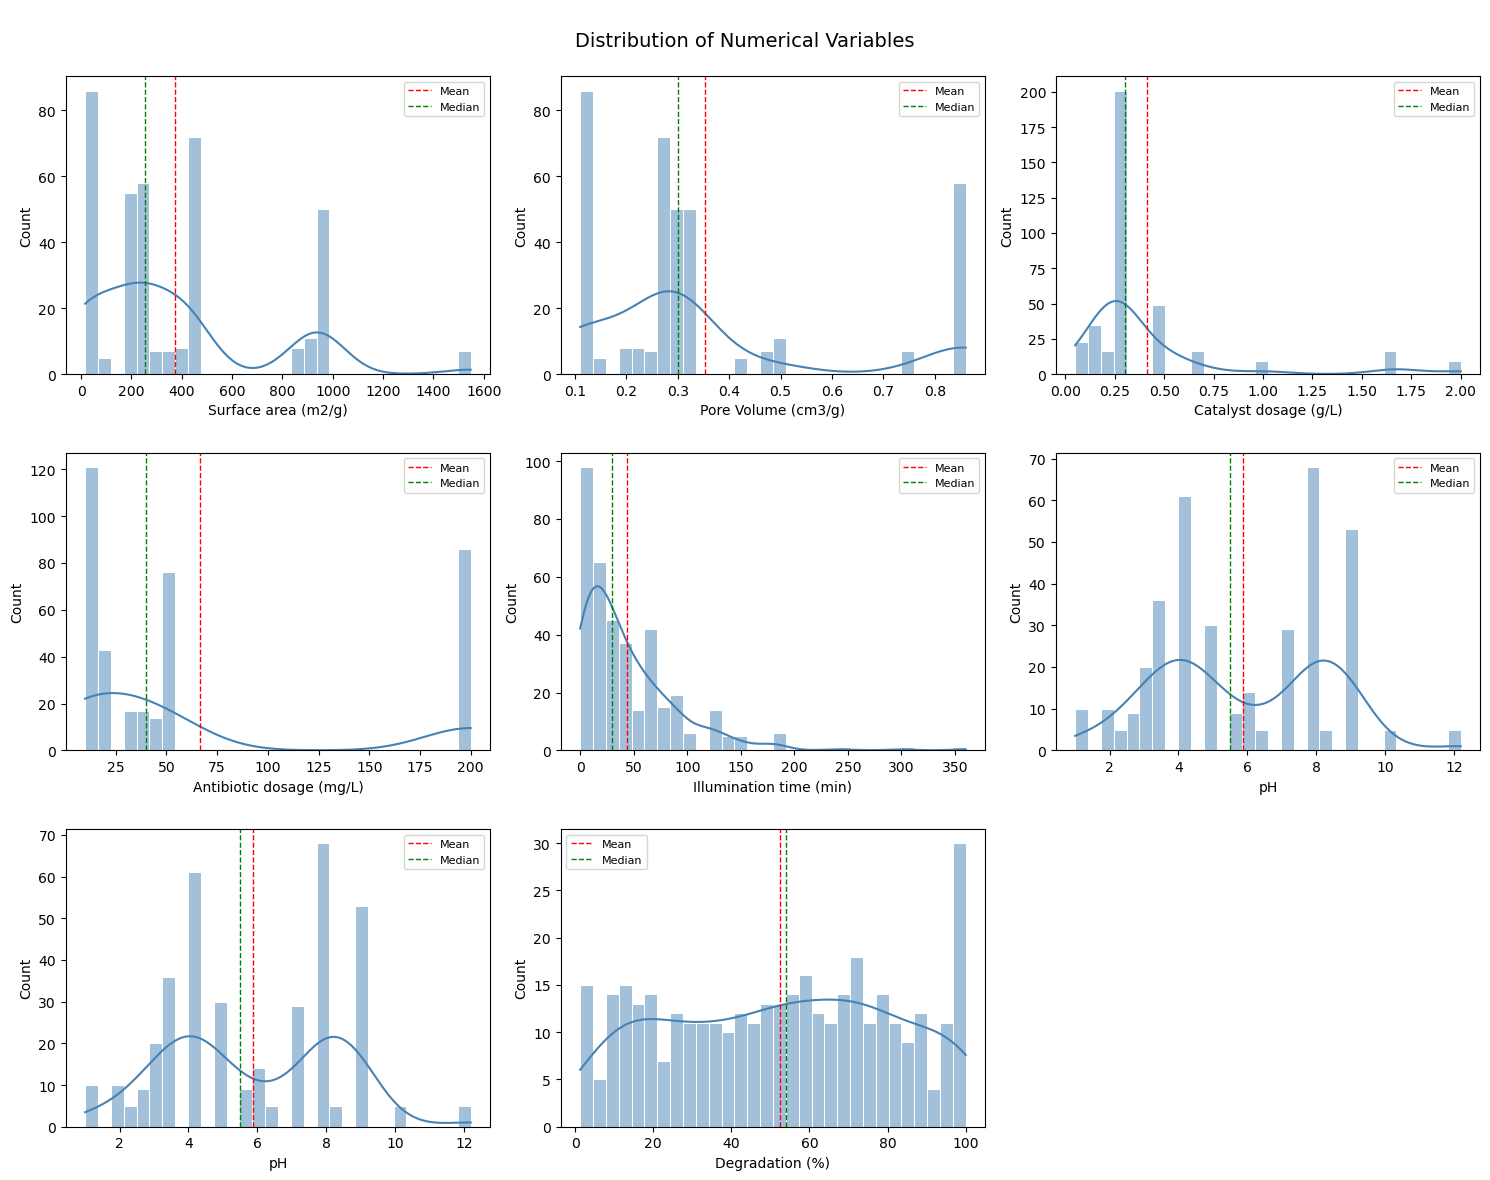

In [111]:
# UNIVARIATE EDA
NUMERIC_COLS = [
    "Surface area (m2/g)",
    "Pore Volume (cm3/g)",
    "Catalyst dosage (g/L)",
    "Antibiotic dosage (mg/L)",
    "Illumination time (min)",
    "pH",
    "pH",
    TARGET_COL,
]

def compute_univariate_stats(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Compute descriptive statistics (min, max, mean, median, std, IQR, skew, n_unique)."""
    rows = []
    for col in cols:
        series = pd.to_numeric(df[col], errors="coerce").dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        rows.append({
            "Variable": col,
            "Min": series.min(),
            "Max": series.max(),
            "Mean": series.mean(),
            "Median": series.median(),
            "Std": series.std(),
            "Q1": q1,
            "Q3": q3,
            "IQR": q3 - q1,
            "Skewness": stats.skew(series),
            "N Unique": series.nunique(),
            "N Obs": series.shape[0],
        })

    stats_df = pd.DataFrame(rows).set_index("Variable").round(3)
    return stats_df


def plot_univariate_distributions(
    df: pd.DataFrame,
    cols: list[str],
    bins: int = 30,
    ncols: int = 3,
) -> None:
    """Plot histogram + KDE for each numeric column in a grid."""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        sns.histplot(series, bins=bins, kde=True, ax=ax, color="steelblue", edgecolor="white")
        ax.axvline(series.mean(), color="red", linestyle="--", linewidth=1, label="Mean")
        ax.axvline(series.median(), color="green", linestyle="--", linewidth=1, label="Median")
        ax.set_title(" ")
        ax.set_xlabel(col)
        ax.legend(fontsize=8)

    # Hide any unused subplots
    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle("\nDistribution of Numerical Variables", fontsize=14)
    plt.tight_layout()
    plt.show()


# Execute Phase
univariate_stats = compute_univariate_stats(df, NUMERIC_COLS)
print("UNIVARIATE DESCRIPTIVE STATISTICS")
display(univariate_stats)

# Distribution plots
plot_univariate_distributions(df, NUMERIC_COLS, bins=30, ncols=3)